# Современные методы анализа данных и машинного обучения, БИ

## Групповой проект №5. Deep Learning

### EDA для маркетплейса Olist

Идея проекта: сделать систему, которая помогает маркетплейсу заранее видеть риск недовольства клиента и дальше использовать это в поддержке для сокращения оттока клиентов.

У нас в проекте две части:

- табличная модель по заказу и по информации о клиенте оценивает риск плохого опыта пользования нашим маркетплейсом;
- текстовая модель в виде RAG-ассистента будет потом использовать отзывы, контекст клиента и базу знаний, чтобы помочь оператору ответить клиенту.

### В рамках EDA смотрю

- какие таблицы есть и как они связаны;
- какие признаки относятся к клиенту, заказу и отзыву;
- как сейчас выглядят повторные покупки в маркетплейсе;
- по каким признакам можно предсказывать недовольство клиента;
- какие признаки влияют на недовольство клиента;
- как построить датасет для табличной модели и датасет для текстовой модели.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.options.display.float_format = '{:.2f}'.format

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 7)

## Раздел 1. Загрузка данных

Датасет: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [ ]:
customers = pd.read_csv('../data/raws/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/raws/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/raws/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raws/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/raws/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/raws/olist_orders_dataset.csv')
products = pd.read_csv('../data/raws/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raws/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/raws/product_category_name_translation.csv')

## Раздел 2. Первичный осмотр таблиц

Посмотрю на основные таблицы, которые нам интересны: заказы, клиенты, товары, оплата, отзывы и доставка.

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


В payments одна строка — это не всегда один заказ, потому что у заказа может быть несколько платежей. Payment_installments — это количество платежей, то есть что-то похожее на рассрочку.

In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Review_score — это оценка от 1 до 5.

In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


Посмотрим на пропуски и дубликаты.

In [ ]:
summary = pd.DataFrame([
    ['orders', orders.shape[0], orders.shape[1], orders.isna().sum().sum(), orders.duplicated().sum()],
    ['customers', customers.shape[0], customers.shape[1], customers.isna().sum().sum(), customers.duplicated().sum()],
    ['order_items', order_items.shape[0], order_items.shape[1], order_items.isna().sum().sum(), order_items.duplicated().sum()],
    ['payments', payments.shape[0], payments.shape[1], payments.isna().sum().sum(), payments.duplicated().sum()],
    ['reviews', reviews.shape[0], reviews.shape[1], reviews.isna().sum().sum(), reviews.duplicated().sum()],
    ['products', products.shape[0], products.shape[1], products.isna().sum().sum(), products.duplicated().sum()],
    ['sellers', sellers.shape[0], sellers.shape[1], sellers.isna().sum().sum(), sellers.duplicated().sum()],
    ['geolocation', geolocation.shape[0], geolocation.shape[1], geolocation.isna().sum().sum(), geolocation.duplicated().sum()],
    ['category_translation', category_translation.shape[0], category_translation.shape[1], category_translation.isna().sum().sum(), category_translation.duplicated().sum()]
], columns=['table', 'rows', 'cols', 'missing_values', 'duplicates'])

summary.sort_values('rows', ascending=False)

,table,rows,cols,missing_values,duplicates
7,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
0,orders,99441,8,4908,0
1,customers,99441,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [ ]:
print('orders')
print(orders.isna().sum())

print('customers')
print(customers.isna().sum())

print('order_items')
print(order_items.isna().sum())

print('payments')
print(payments.isna().sum())

print('reviews')
print(reviews.isna().sum())

print('products')
print(products.isna().sum())

print('sellers')
print(sellers.isna().sum())

print('geolocation')
print(geolocation.isna().sum())

print('category_translation')
print(category_translation.isna().sum())

orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comm

Пропуски есть в текстовых отзывах, потому что не каждый клиент пишет комментарий. Иногда бывают пропуски в датах доставки, похоже, для тех заказов, которые не дошли до статуса доставленных.

Полные дубли проверили. Теперь проверю дубликаты по основным ID, потому что в будущем придется таблицы совмещать.

In [ ]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [ ]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [ ]:
customers['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [ ]:
order_items.duplicated(['order_id', 'order_item_id']).sum()

np.int64(0)

In [ ]:
payments.duplicated(['order_id', 'payment_sequential']).sum()

np.int64(0)

In [ ]:
reviews['review_id'].duplicated().sum()

np.int64(814)

In [ ]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [ ]:
products['product_id'].duplicated().sum()

np.int64(0)

In [ ]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

## Раздел 3. Как таблицы связаны между собой

Ключевые ID, которые можно использовать для связей:

- order_id — конкретный заказ;
- customer_id — клиент внутри конкретного заказа;
- customer_unique_id — уникальный клиент;
- product_id — товар;
- seller_id — продавец.

Здесь важно не перепутать customer_id и customer_unique_id. Customer_id относится к заказу, а customer_unique_id больше похож на реального уникального клиента.

In [ ]:
orders['order_id'].nunique(), orders.shape[0]

(99441, 99441)

In [ ]:
customers['customer_id'].nunique(), customers['customer_unique_id'].nunique()

(99441, 96096)

In [ ]:
orders['customer_id'].nunique(), customers['customer_id'].nunique()

(99441, 99441)

Вывод: для таблицы заказов можно соединяться по customer_id, но для анализа retention и повторных покупок нужен customer_unique_id.

Нас интересует информация о клиенте именно по customer_unique_id, потому что это уникальный клиент, а не клиент внутри одного заказа.

## Раздел 4. Даты и динамика заказов

Сейчас даты в таблицах в формате object, переделаю в datetime.

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [ ]:
orders['order_purchase_timestamp'].agg(['min', 'max'])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [ ]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
orders['order_status'].value_counts(normalize=True) * 100

order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

In [ ]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_orders = orders.groupby('order_month')['order_id'].nunique()
monthly_orders.head()

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Name: order_id, dtype: int64

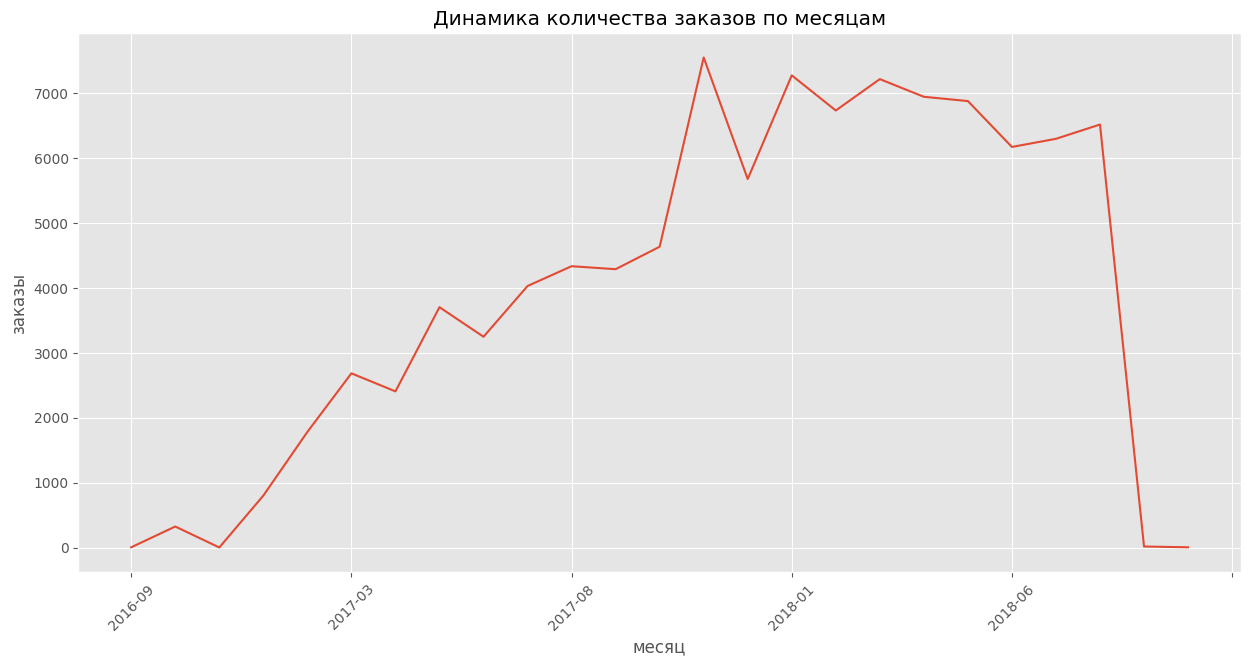

In [ ]:
monthly_orders.plot()
plt.title('Динамика количества заказов по месяцам')
plt.xlabel('месяц')
plt.ylabel('заказы')
plt.xticks(rotation=45)
plt.show()

Вывод: данные идут примерно с сентября 2016 до октября 2018. Основная нормальная часть датасета начинается в 2017 году. В конце 2018 есть обрыв, поэтому с retention-таргетами надо быть осторожным: для последних клиентов мы просто не знаем, вернулись бы они позже или нет.

Весь датасет я здесь не обрезаю, но дальше для проверки возврата за 90 дней будуучитывать.

## Раздел 5. Оплаты и стоимость заказов

Посмотрим, что покупают, сколько это стоит, какие основные метрики по доставке и какие есть способы оплаты.

In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

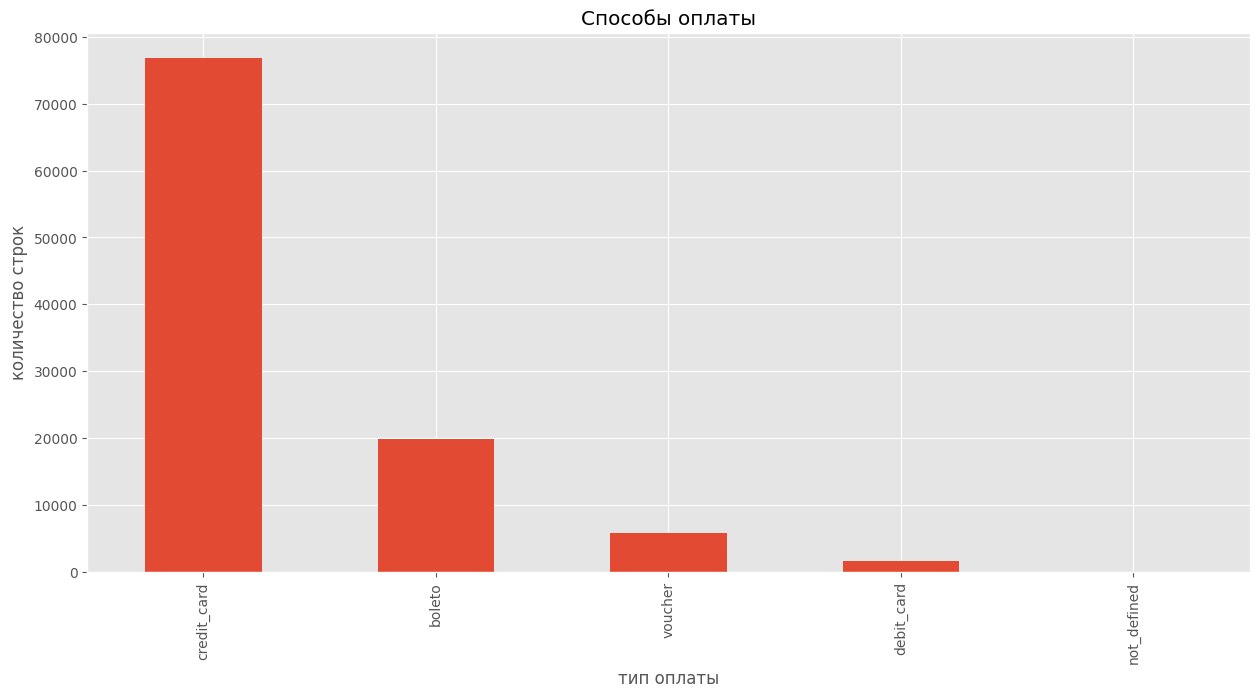

In [ ]:
payments['payment_type'].value_counts().plot(kind='bar')
plt.title('Способы оплаты')
plt.xlabel('тип оплаты')
plt.ylabel('количество строк')
plt.show()

In [ ]:
payment_agg = payments.groupby('order_id').agg({'payment_value': 'sum', 'payment_installments': 'max', 'payment_type': 'nunique'}).reset_index()

payment_agg.columns = ['order_id', 'payment_value', 'payment_installments', 'payment_type_count']
payment_agg.head()

,order_id,payment_value,payment_installments,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


Агрегирую оплаты на уровень заказа: payment_value складываю, payment_installments беру максимальный, а payment_type считаю как количество разных способов оплаты внутри заказа.

In [ ]:
main_payment = payments.groupby('order_id')['payment_type'].agg(lambda x: x.mode().iloc[0]).reset_index()
main_payment.columns = ['order_id', 'main_payment_type']

payment_agg = payment_agg.merge(main_payment, on='order_id', how='left')
payment_agg.head()

,order_id,payment_value,payment_installments,payment_type_count,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [ ]:
payment_agg['payment_value'].describe()

count   99440.00
mean      160.99
std       221.95
min         0.00
25%        62.01
50%       105.29
75%       176.97
max     13664.08
Name: payment_value, dtype: float64

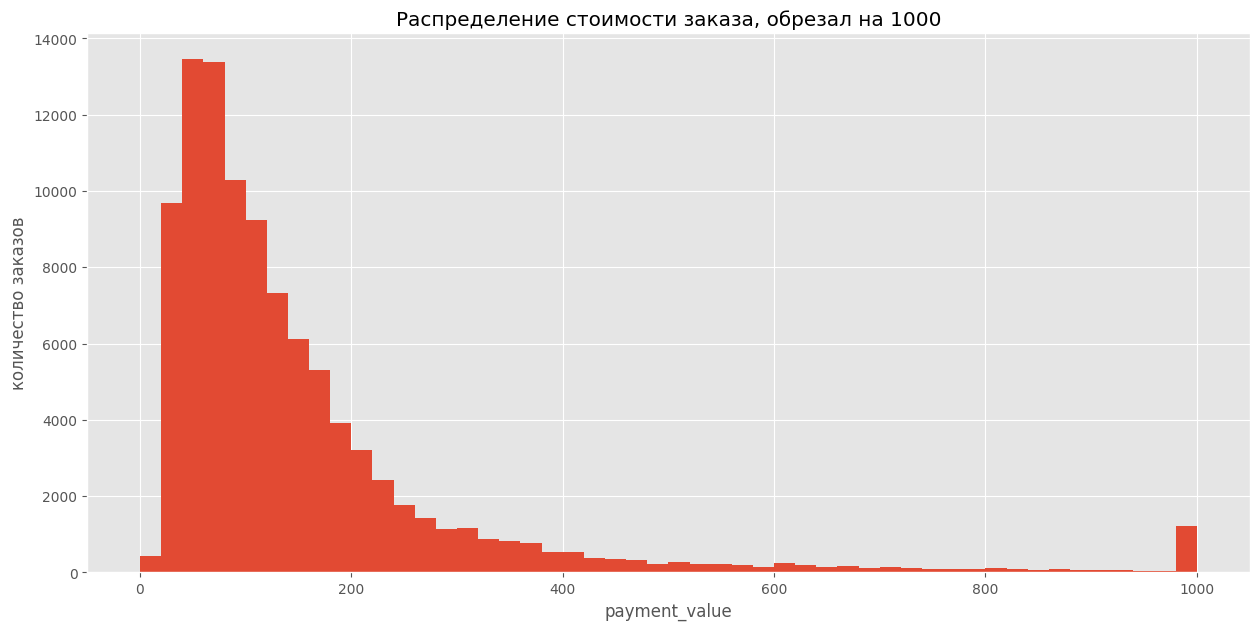

In [ ]:
payment_agg['payment_value'].clip(upper=1000).hist(bins=50)
plt.title('Распределение стоимости заказа, обрезал на 1000')
plt.xlabel('payment_value')
plt.ylabel('количество заказов')
plt.show()

## Раздел 6. Товары и категории

Соберу товары с категориями. Перевод категорий на английский уже есть в отдельной таблице.

In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [ ]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna(products['product_category_name'])
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00,housewares


In [ ]:
items = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
items['product_category_name_english'] = items['product_category_name_english'].fillna('unknown')
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools


In [ ]:
item_agg = items.groupby('order_id').agg({'order_item_id': 'count', 'product_id': 'nunique', 'seller_id': 'nunique', 'price': 'sum', 'freight_value': 'sum'}).reset_index()

item_agg.columns = ['order_id', 'order_item_count', 'unique_products', 'unique_sellers', 'items_price', 'freight_value']
item_agg.head()

,order_id,order_item_count,unique_products,unique_sellers,items_price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


In [ ]:
main_category = items.groupby('order_id')['product_category_name_english'].agg(lambda x: x.mode().iloc[0]).reset_index()
main_category.columns = ['order_id', 'main_category']

item_agg = item_agg.merge(main_category, on='order_id', how='left')
item_agg.head()

,order_id,order_item_count,unique_products,unique_sellers,items_price,freight_value,main_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,garden_tools


Теперь у каждого заказа есть количество товаров, количество уникальных товаров, количество продавцов, сумма товаров, стоимость доставки и основная категория.

## Раздел 7. Отзывы

Теперь посмотрим на отзывы:

- как распределены оценки;
- сколько плохих отзывов;
- сколько отзывов с текстом;
- можно ли из этого сделать целевую переменную для модели.

In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [ ]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

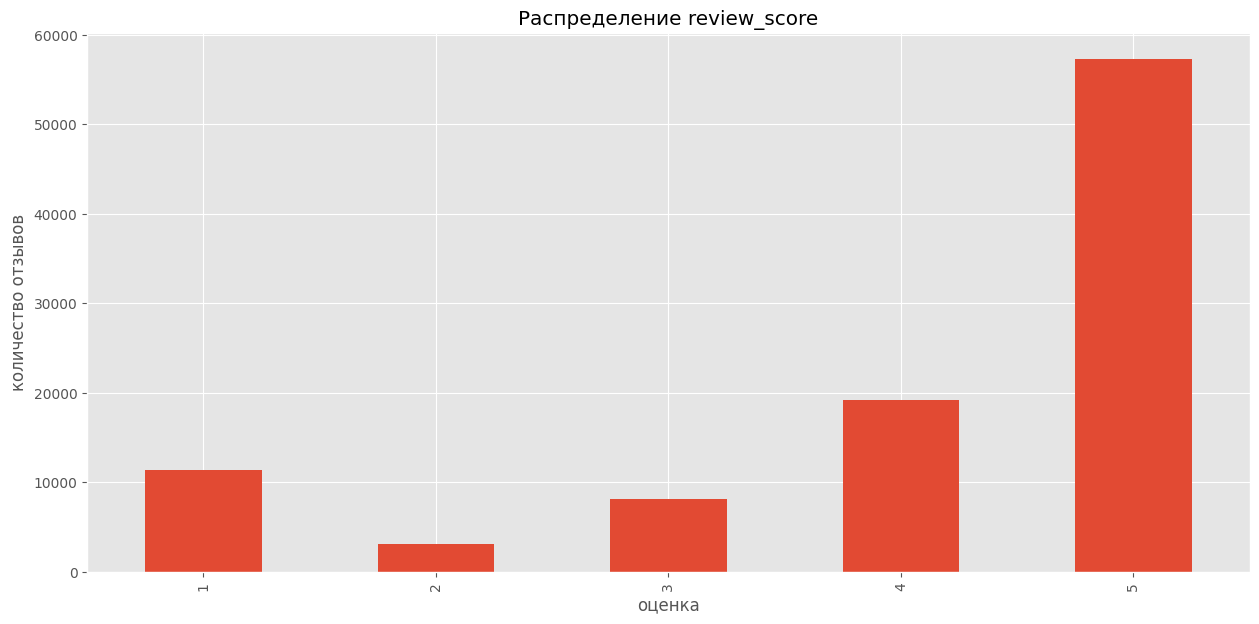

In [ ]:
reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение review_score')
plt.xlabel('оценка')
plt.ylabel('количество отзывов')
plt.show()

In [ ]:
reviews['bad_review'] = (reviews['review_score'] <= 2).astype(int)
reviews['bad_review'].mean() * 100

np.float64(14.688986535515603)

In [ ]:
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')
reviews['comment_len'] = reviews['review_comment_message'].str.len()
reviews['has_text'] = (reviews['comment_len'] > 0).astype(int)

reviews[['review_score', 'review_comment_message', 'comment_len', 'has_text']].head()

,review_score,review_comment_message,comment_len,has_text
0,4,,0,0
1,5,,0,0
2,5,,0,0
3,5,Recebi bem antes do prazo estipulado.,37,1
4,5,Parabéns lojas lannister adorei comprar pela I...,100,1


In [ ]:
reviews['has_text'].mean() * 100

np.float64(41.29746835443038)

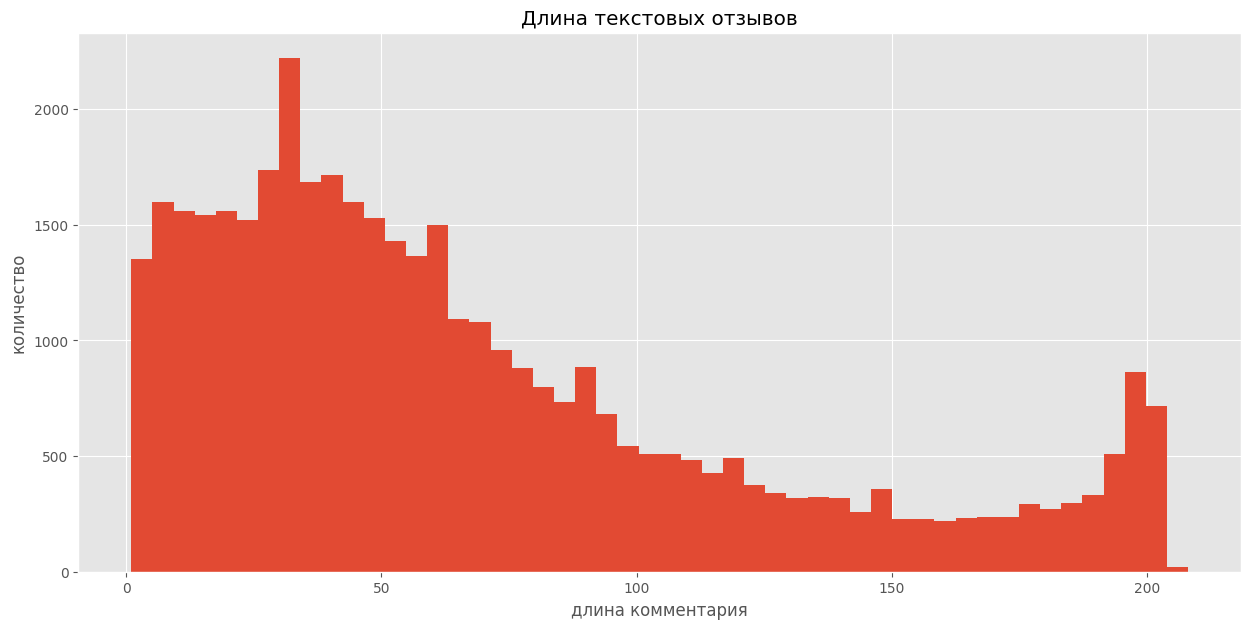

In [ ]:
reviews[reviews['comment_len'] > 0]['comment_len'].clip(upper=1000).hist(bins=50)
plt.title('Длина текстовых отзывов')
plt.xlabel('длина комментария')
plt.ylabel('количество')
plt.show()

Вывод: плохих отзывов не так мало, но и не половина датасета. Кажется хорошей идеей сделать целевой переменной значение review_score меньше или равно 2.

Текст есть почти в половине случаев, и для неструктурированных данных нам этого будет достаточно.

## Раздел 8. Собираю таблицу на уровне заказа

Чтобы дальше смотреть доставку, категории, географию, оплату и отзывы в одном месте, соединю основные таблицы на уровень заказа. Одна строка в такой таблице — один заказ.

In [ ]:
review_agg = reviews.groupby('order_id').agg({'review_score': 'mean', 'bad_review': 'max', 'has_text': 'max', 'comment_len': 'mean'}).reset_index()

review_agg.head()

,order_id,review_score,bad_review,has_text,comment_len
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,0,1,46.00
1,00018f77f2f0320c557190d7a144bdd3,4.00,0,0,0.00
2,000229ec398224ef6ca0657da4fc703e,5.00,0,1,90.00
3,00024acbcdf0a6daa1e931b038114c75,4.00,0,0,0.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00,0,1,39.00


In [ ]:
order_level = orders.merge(customers, on='customer_id', how='left')
order_level = order_level.merge(item_agg, on='order_id', how='left')
order_level = order_level.merge(payment_agg, on='order_id', how='left')
order_level = order_level.merge(review_agg, on='order_id', how='left')

order_level.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,...,freight_value,main_category,payment_value,payment_installments,payment_type_count,main_payment_type,review_score,bad_review,has_text,comment_len
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,...,8.72,housewares,38.71,1.00,2.00,voucher,4.00,0.00,1.00,170.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,...,22.76,perfumery,141.46,1.00,1.00,boleto,4.00,0.00,1.00,20.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,...,19.22,auto,179.12,3.00,1.00,credit_card,5.00,0.00,0.00,0.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977,...,27.20,pet_shop,72.20,1.00,1.00,credit_card,5.00,0.00,1.00,105.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,...,8.72,stationery,28.62,1.00,1.00,credit_card,5.00,0.00,0.00,0.00


In [ ]:
order_level.shape

(99441, 27)

У части проблемных заказов нет строк в order_items, поэтому для суммы товаров и доставки ставлю 0. Сам факт проблемного статуса заказа отдельно остается в order_status и not_delivered.

In [ ]:
order_level['main_category'] = order_level['main_category'].fillna('unknown')
order_level['items_price'] = order_level['items_price'].fillna(0)
order_level['freight_value'] = order_level['freight_value'].fillna(0)

order_level['order_total'] = order_level['items_price'] + order_level['freight_value']
order_level['freight_share'] = order_level['freight_value'] / order_level['order_total'].replace(0, np.nan)

order_level['delivery_days'] = (order_level['order_delivered_customer_date'] - order_level['order_purchase_timestamp']).dt.days
order_level['estimated_delivery_days'] = (order_level['order_estimated_delivery_date'] - order_level['order_purchase_timestamp']).dt.days
order_level['delay_days'] = (order_level['order_delivered_customer_date'] - order_level['order_estimated_delivery_date']).dt.days
order_level['is_late'] = (order_level['delay_days'] > 0).astype(int)

order_level['risk_dissatisfaction'] = (order_level['review_score'] <= 2).astype(int)
order_level['review_score_round'] = order_level['review_score'].round()

order_level['not_delivered'] = (order_level['order_status'] != 'delivered').astype(int)
order_level['multiple_sellers'] = (order_level['unique_sellers'] > 1).astype(int)
order_level['high_installments'] = (order_level['payment_installments'] >= 6).astype(int)
order_level['expensive_order'] = (order_level['order_total'] >= order_level['order_total'].quantile(0.8)).astype(int)

order_level[['order_id', 'customer_unique_id', 'order_total', 'delivery_days', 'delay_days', 'review_score', 'risk_dissatisfaction', 'not_delivered', 'multiple_sellers', 'high_installments', 'expensive_order']].head()

,order_id,customer_unique_id,order_total,delivery_days,delay_days,review_score,risk_dissatisfaction,not_delivered,multiple_sellers,high_installments,expensive_order
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,38.71,8.00,-8.00,4.00,0,0,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,141.46,13.00,-6.00,4.00,0,0,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,179.12,9.00,-18.00,5.00,0,0,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,72.20,13.00,-13.00,5.00,0,0,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,28.62,2.00,-10.00,5.00,0,0,0,0,0


In [ ]:
order_level[['order_total', 'freight_value', 'freight_share', 'delivery_days', 'delay_days', 'review_score']].describe()

,order_total,freight_value,freight_share,delivery_days,delay_days,review_score
count,99441.00,99441.00,98666.00,96476.00,96476.00,98673.00
mean,159.33,22.65,0.21,12.09,-11.88,4.09
std,220.06,21.66,0.13,9.55,10.18,1.35
min,0.00,0.00,0.00,0.00,-147.00,1.00
25%,61.05,13.72,0.12,6.00,-17.00,4.00
50%,104.56,17.09,0.18,10.00,-12.00,5.00
75%,176.00,23.92,0.28,15.00,-7.00,5.00
max,13664.08,1794.96,0.96,209.00,188.00,5.00


теперь в таблице одна строка - один заказ. Тут есть признаки заказа, доставки, оплаты, категории и целевая переменная плохого опыта.

## Раздел 9. Связь доставки с отзывами

Есть гипотеза, что если заказ опоздал или доставка была долгой, клиент чаще ставит плохую оценку.

In [ ]:
order_level['is_late'].mean() * 100

np.float64(6.571736004263835)

In [ ]:
order_level.groupby('review_score_round')[['delivery_days', 'delay_days', 'is_late']].mean()

,delivery_days,delay_days,is_late
review_score_round,,,
1.00,20.88,-4.03,0.30
2.00,16.22,-8.62,0.18
3.00,13.78,-10.78,0.08
4.00,11.84,-12.38,0.03
5.00,10.21,-13.38,0.02


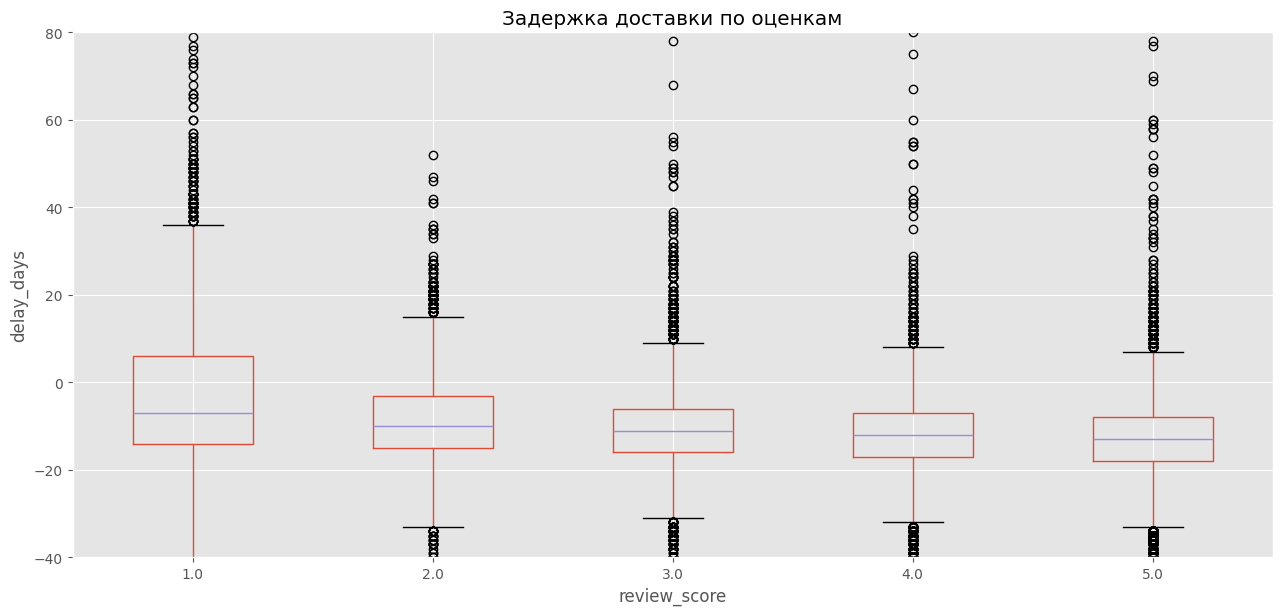

In [ ]:
order_level.boxplot(column='delay_days', by='review_score_round')
plt.title('Задержка доставки по оценкам')
plt.suptitle('')
plt.xlabel('review_score')
plt.ylabel('delay_days')
plt.ylim(-40, 80)
plt.show()

In [ ]:
late_review = order_level.groupby('is_late')['risk_dissatisfaction'].mean() * 100
late_review

is_late
0   11.27
1   60.89
Name: risk_dissatisfaction, dtype: float64

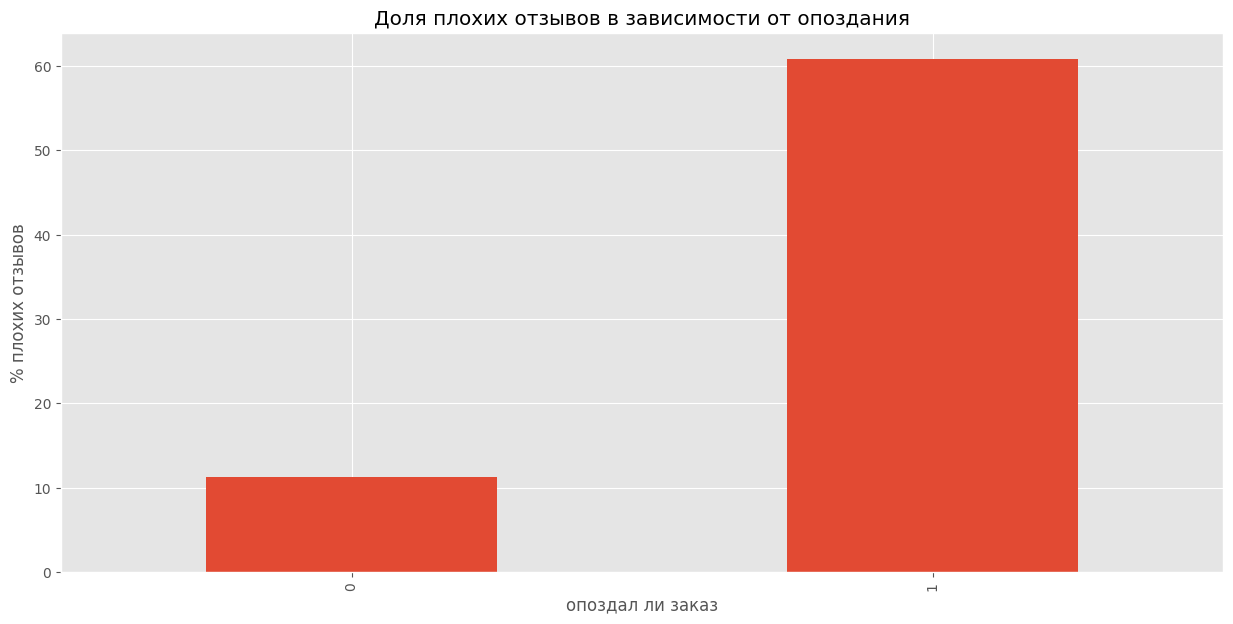

In [ ]:
late_review.plot(kind='bar')
plt.title('Доля плохих отзывов в зависимости от опоздания')
plt.xlabel('опоздал ли заказ')
plt.ylabel('% плохих отзывов')
plt.show()

Вывод: доставка очень важна. Если заказ опоздал, процент плохих отзывов сильно растет. Если клиент недоволен, оператору нужно увидеть, была ли у него проблема с доставкой.

## Раздел 10. Клиенты и повторные покупки

Теперь посмотрим retention. Напомню, что нужно использовать customer_unique_id, как исследовал ранее.

In [ ]:
orders_per_customer = order_level.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False)
orders_per_customer.head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
Name: order_id, dtype: int64

In [ ]:
orders_per_customer.describe()

count   96096.00
mean        1.03
std         0.21
min         1.00
25%         1.00
50%         1.00
75%         1.00
max        17.00
Name: order_id, dtype: float64

In [ ]:
(orders_per_customer > 1).mean() * 100

np.float64(3.1187562437562435)

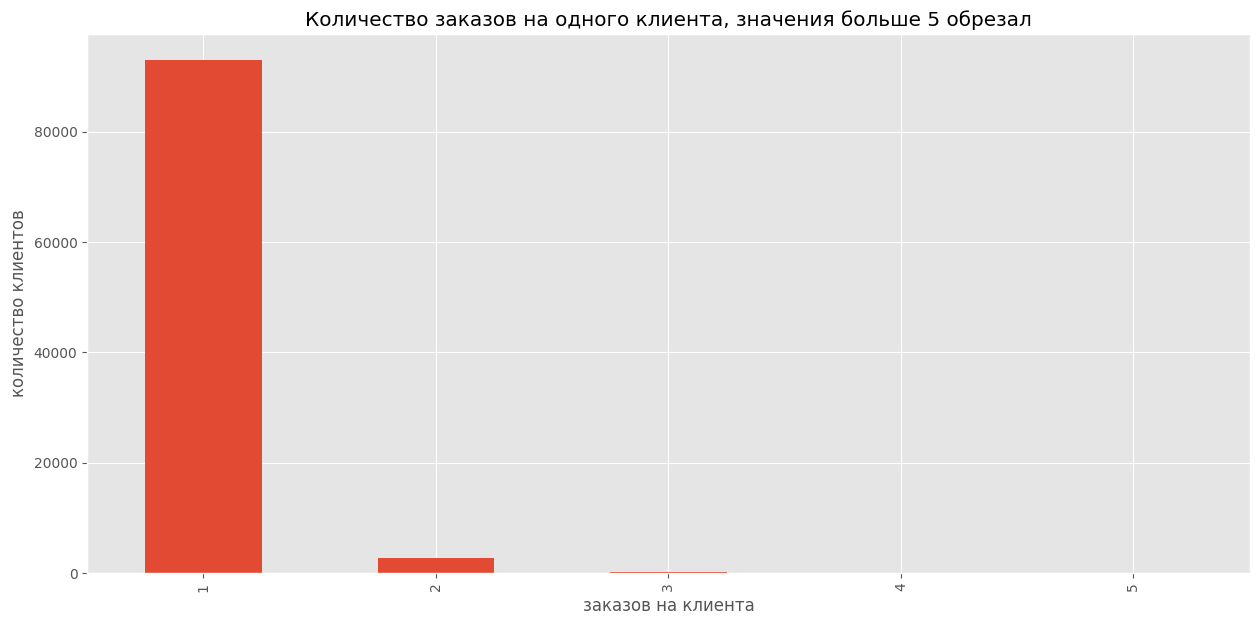

In [ ]:
orders_per_customer.clip(upper=5).value_counts().sort_index().plot(kind='bar')
plt.title('Количество заказов на одного клиента, значения больше 5 обрезал')
plt.xlabel('заказов на клиента')
plt.ylabel('количество клиентов')
plt.show()

В Olist почти все клиенты покупают один раз. Поэтому будет неинформативно, если целевой переменной сделать признак “не вернулся в течение 90 дней” типа он будет очень несбалансирован.

Но надежд не оставляем. Возможно, получится в качестве целевой переменной взять что-то, связанное с риском недовольства клиента по его плохому отзыву.

Для проверки 90-дневного возврата беру первый заказ клиента, ищу дату следующего заказа и отдельно проверяю, можно ли для этого клиента вообще наблюдать следующие 90 дней.

In [ ]:
customer_orders = order_level.sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
customer_orders['next_order_date'] = customer_orders.groupby('customer_unique_id')['order_purchase_timestamp'].shift(-1)
customer_orders['days_to_next_order'] = (customer_orders['next_order_date'] - customer_orders['order_purchase_timestamp']).dt.days

first_orders = customer_orders.groupby('customer_unique_id').first().reset_index()
last_date = customer_orders['order_purchase_timestamp'].max()
first_orders['can_check_90_days'] = first_orders['order_purchase_timestamp'] <= last_date - pd.Timedelta(days=90)
first_orders['returned_90_days'] = first_orders['days_to_next_order'] <= 90
first_orders['risk_no_return_90d'] = ((first_orders['can_check_90_days']) & (~first_orders['returned_90_days'])).astype(int)

first_orders[['customer_unique_id', 'order_purchase_timestamp', 'days_to_next_order', 'can_check_90_days', 'returned_90_days', 'risk_no_return_90d']].head()

,customer_unique_id,order_purchase_timestamp,days_to_next_order,can_check_90_days,returned_90_days,risk_no_return_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,NaN,True,False,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,NaN,True,False,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,NaN,True,False,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,NaN,True,False,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,NaN,True,False,1


In [ ]:
first_orders[first_orders['can_check_90_days']]['risk_no_return_90d'].value_counts(normalize=True) * 100

risk_no_return_90d
1   97.74
0    2.26
Name: proportion, dtype: float64

Видно, что пользователи почти в 100% случаев не возвращаются за повторной покупкой в течение 90 дней.

Поэтому дальше для нас в табличной модели целевой переменной будет риск недовольства.

## Раздел 11. Категории товаров

Теперь посмотрю, какие категории чаще дают плохие отзывы. Это полезно и для признаков модели, и для бизнес-выводов.

In [ ]:
category_stats = order_level.groupby('main_category').agg({'order_id': 'nunique', 'order_total': 'mean', 'review_score': 'mean', 'risk_dissatisfaction': 'mean', 'is_late': 'mean'}).reset_index()

category_stats.columns = ['category', 'orders', 'avg_order_total', 'avg_review_score', 'bad_review_share', 'late_share']
category_stats['bad_review_share'] = category_stats['bad_review_share'] * 100
category_stats['late_share'] = category_stats['late_share'] * 100

category_stats.sort_values('orders', ascending=False).head(15)

,category,orders,avg_order_total,avg_review_score,bad_review_share,late_share
7,bed_bath_table,9384,133.96,3.97,16.35,7.34
43,health_beauty,8810,163.82,4.18,12.51,7.38
67,sports_leisure,7668,150.49,4.18,12.69,6.43
15,computers_accessories,6679,159.28,4.03,15.89,6.24
39,furniture_decor,6350,142.82,4.02,16.16,7.02
49,housewares,5811,133.34,4.15,12.79,5.30
73,watches_gifts,5584,232.64,4.07,14.83,7.27
70,telephony,4177,94.27,4.01,15.20,6.97
5,auto,3891,176.72,4.09,14.32,7.14
71,toys,3841,144.96,4.20,12.29,6.27


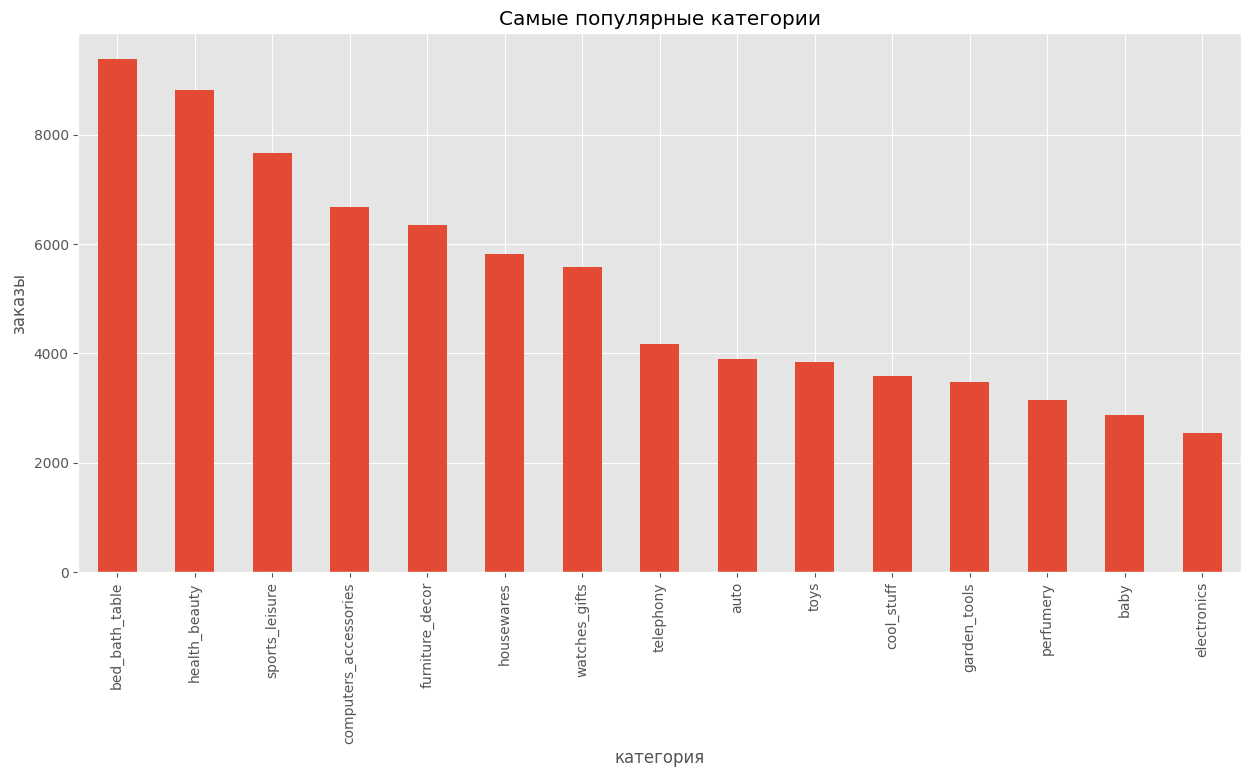

In [ ]:
category_stats.sort_values('orders', ascending=False).head(15).set_index('category')['orders'].plot(kind='bar')
plt.title('Самые популярные категории')
plt.xlabel('категория')
plt.ylabel('заказы')
plt.show()

In [ ]:
bad_categories = category_stats[category_stats['orders'] >= 500].sort_values('bad_review_share', ascending=False)
bad_categories.head(15)

,category,orders,avg_order_total,avg_review_score,bad_review_share,late_share
72,unknown,2168,93.34,3.16,39.62,4.38
57,office_furniture,1263,270.16,3.63,22.17,8.00
7,bed_bath_table,9384,133.96,3.97,16.35,7.34
39,furniture_decor,6350,142.82,4.02,16.16,7.02
15,computers_accessories,6679,159.28,4.03,15.89,6.24
6,baby,2870,169.77,4.05,15.68,7.87
70,telephony,4177,94.27,4.01,15.20,6.97
73,watches_gifts,5584,232.64,4.07,14.83,7.27
5,auto,3891,176.72,4.09,14.32,7.14
16,consoles_games,1060,167.68,4.07,14.06,5.85


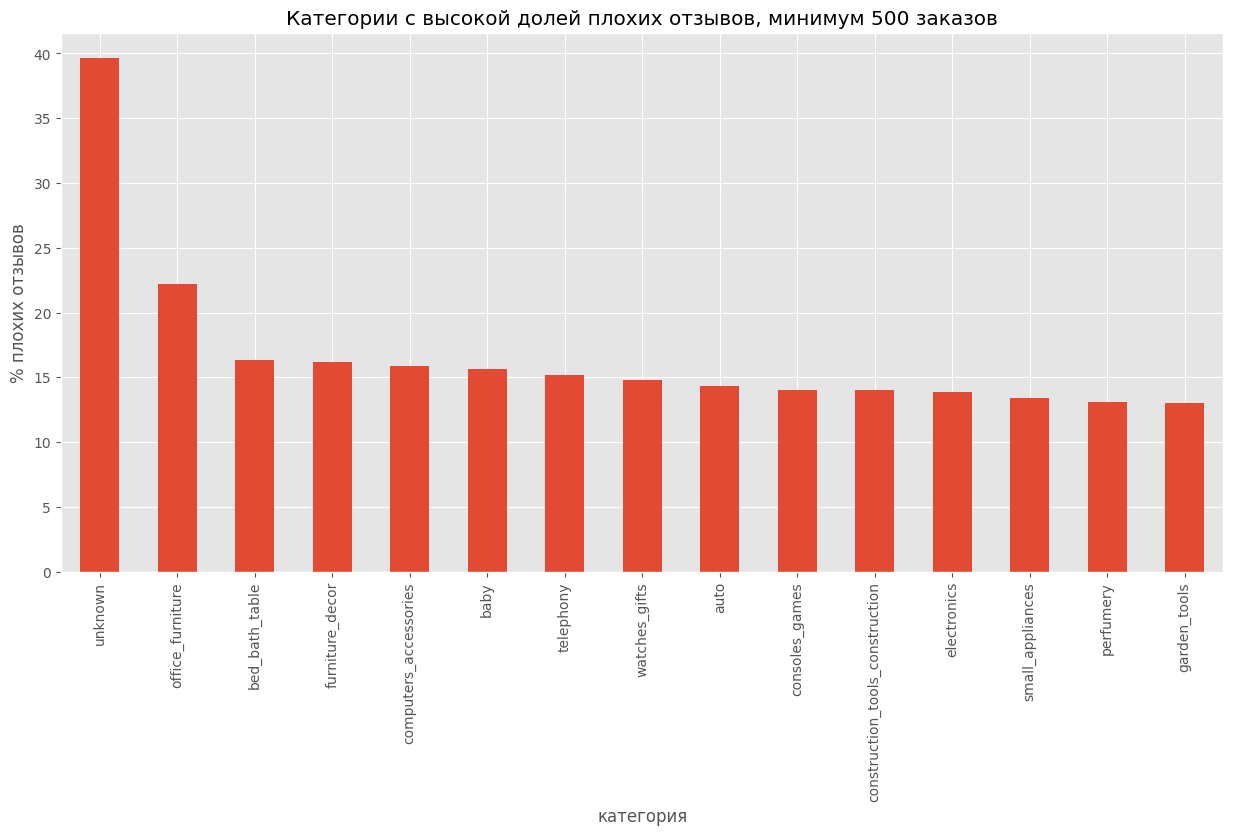

In [ ]:
bad_categories.head(15).set_index('category')['bad_review_share'].plot(kind='bar')
plt.title('Категории с высокой долей плохих отзывов, минимум 500 заказов')
plt.xlabel('категория')
plt.ylabel('% плохих отзывов')
plt.show()

Можем сделать вывод, что категория хороший признак, потому что некоторые категории имеют заметно больше плохих отзывов. Это можно использовать и в модели, и в последующих бизнес-выводах.

## Раздел 12. География

Посмотрю штаты клиентов. География может влиять на доставку и риск плохого опыта.

In [ ]:
state_stats = order_level.groupby('customer_state').agg({'order_id': 'nunique', 'order_total': 'mean', 'review_score': 'mean', 'risk_dissatisfaction': 'mean', 'is_late': 'mean', 'delay_days': 'mean'}).reset_index()

state_stats.columns = ['state', 'orders', 'avg_order_total', 'avg_review_score', 'bad_review_share', 'late_share', 'avg_delay_days']
state_stats['bad_review_share'] = state_stats['bad_review_share'] * 100
state_stats['late_share'] = state_stats['late_share'] * 100

state_stats.sort_values('orders', ascending=False).head(15)

,state,orders,avg_order_total,avg_review_score,bad_review_share,late_share,avg_delay_days
25,SP,41746,141.85,4.17,12.51,4.36,-11.08
18,RJ,12852,165.71,3.88,20.38,11.63,-11.77
10,MG,11635,159.53,4.14,13.17,4.47,-13.24
22,RS,5466,162.06,4.13,13.25,5.95,-13.91
17,PR,5045,158.76,4.18,12.35,3.94,-13.31
23,SC,3637,167.78,4.07,14.54,8.00,-11.51
4,BA,3380,180.92,3.86,18.70,11.72,-10.79
6,DF,2140,165.06,4.07,14.77,5.51,-12.05
7,ES,2033,159.76,4.04,14.71,10.53,-10.50
8,GO,2020,172.13,4.04,14.60,6.34,-12.19


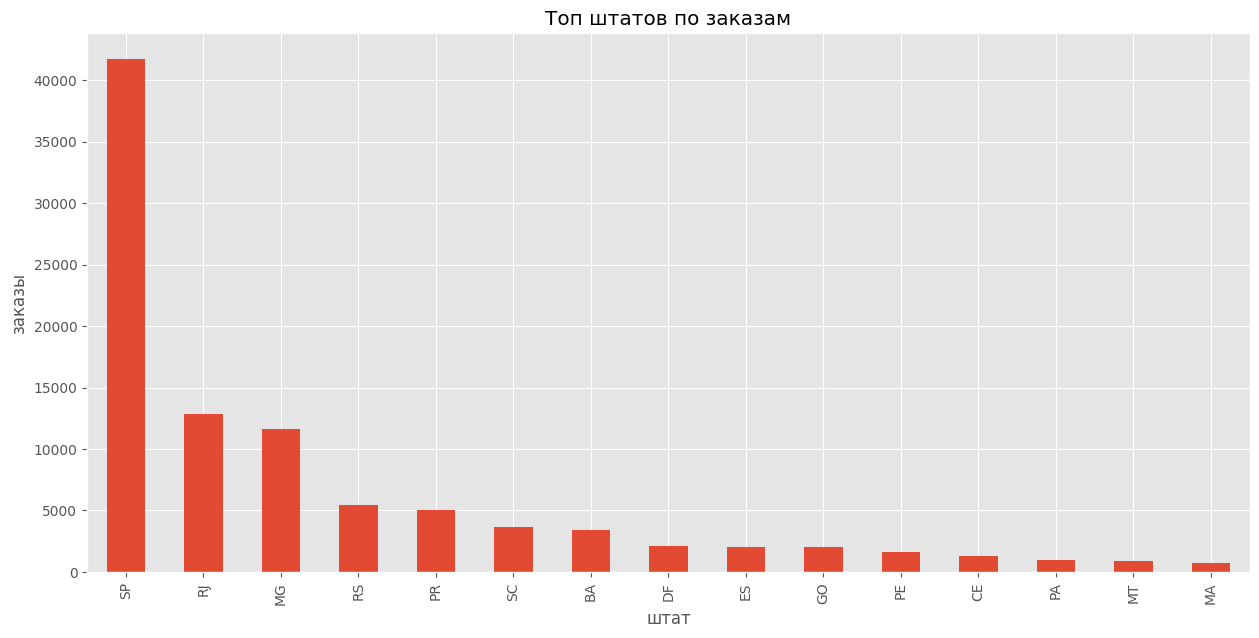

In [ ]:
state_stats.sort_values('orders', ascending=False).head(15).set_index('state')['orders'].plot(kind='bar')
plt.title('Топ штатов по заказам')
plt.xlabel('штат')
plt.ylabel('заказы')
plt.show()

In [ ]:
state_stats[state_stats['orders'] >= 500].sort_values('bad_review_share', ascending=False).head(15)

,state,orders,avg_order_total,avg_review_score,bad_review_share,late_share,avg_delay_days
9,MA,747,202.37,3.76,21.69,16.73,-9.57
18,RJ,12852,165.71,3.88,20.38,11.63,-11.77
5,CE,1336,206.29,3.85,19.54,13.17,-10.80
13,PA,975,223.23,3.85,19.28,10.87,-14.07
4,BA,3380,180.92,3.86,18.70,11.72,-10.79
15,PE,1652,195.06,4.01,16.59,9.26,-13.29
14,PB,536,263.04,4.02,16.42,10.07,-13.26
6,DF,2140,165.06,4.07,14.77,5.51,-12.05
7,ES,2033,159.76,4.04,14.71,10.53,-10.50
8,GO,2020,172.13,4.04,14.60,6.34,-12.19


География тоже может быть хорошим признаком, потому что в каких-то штатах больше заказов, а где-то хуже доставка и выше доля плохих оценок отзывов.

## Раздел 13. Что кроме доставки и географии может быть связано с плохими отзывами

Посмотрю на статус заказа, наличие нескольких поставщиков внутри одного заказа, дорогие заказы и количество платежей.

In [ ]:
status_bad = order_level.groupby('order_status')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()
status_bad['bad_review_share'] = status_bad['mean'] * 100
status_bad.sort_values('bad_review_share', ascending=False)

,order_status,count,mean,bad_review_share
5,processing,301,0.91,90.70
7,unavailable,609,0.83,82.76
4,invoiced,314,0.81,80.57
1,canceled,625,0.74,74.24
6,shipped,1107,0.65,64.59
0,approved,2,0.50,50.00
2,created,5,0.40,40.00
3,delivered,96478,0.13,12.68


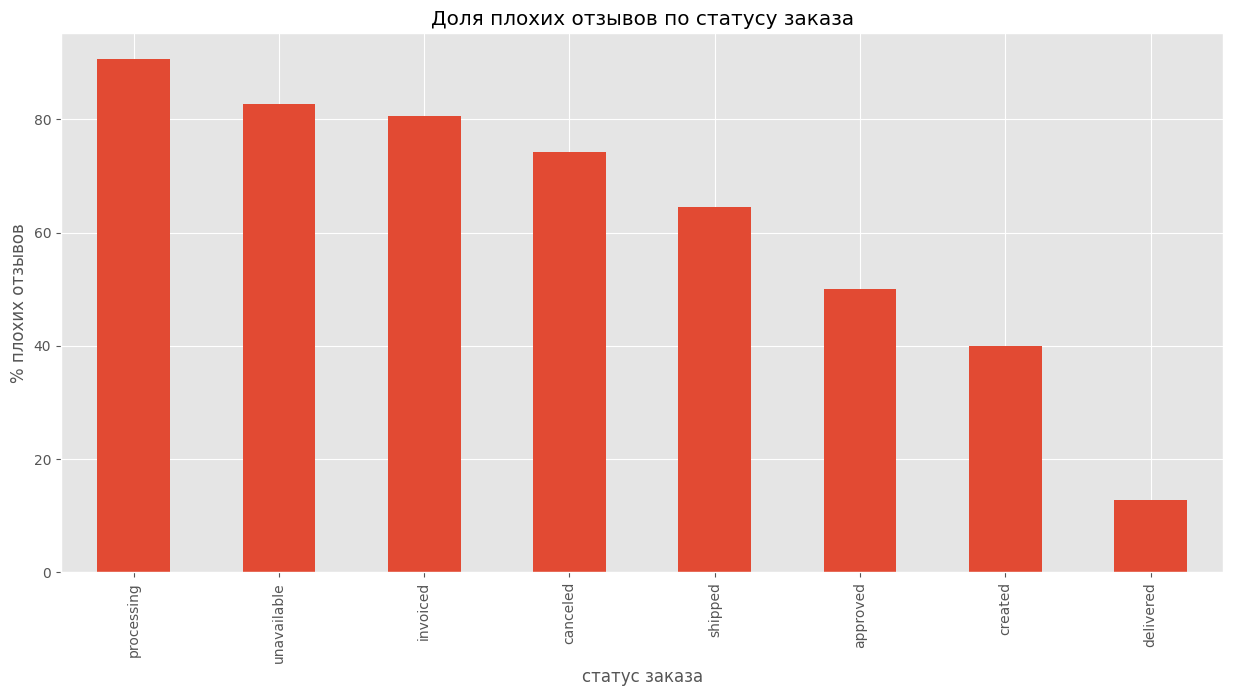

In [ ]:
status_bad.sort_values('bad_review_share', ascending=False).set_index('order_status')['bad_review_share'].plot(kind='bar')
plt.title('Доля плохих отзывов по статусу заказа')
plt.xlabel('статус заказа')
plt.ylabel('% плохих отзывов')
plt.show()

Видно, что если заказ не дошел до нормального delivered, то доля плохих отзывов резко выше. Это логично, потому что клиенту не так важно, на каком именно этапе проблема, если заказ не был нормально завершен.

In [ ]:
delivered_orders = order_level[order_level['order_status'] == 'delivered'].copy()

delivered_orders.groupby('multiple_sellers')['risk_dissatisfaction'].agg(['count', 'mean'])

,count,mean
multiple_sellers,,
0,95203,0.12
1,1275,0.47


In [ ]:
seller_bad = delivered_orders.groupby('unique_sellers')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()
seller_bad['bad_review_share'] = seller_bad['mean'] * 100
seller_bad

,unique_sellers,count,mean,bad_review_share
0,1.00,95203,0.12,12.23
1,2.00,1216,0.46,45.89
2,3.00,54,0.61,61.11
3,4.00,3,1.00,100.00
4,5.00,2,1.00,100.00


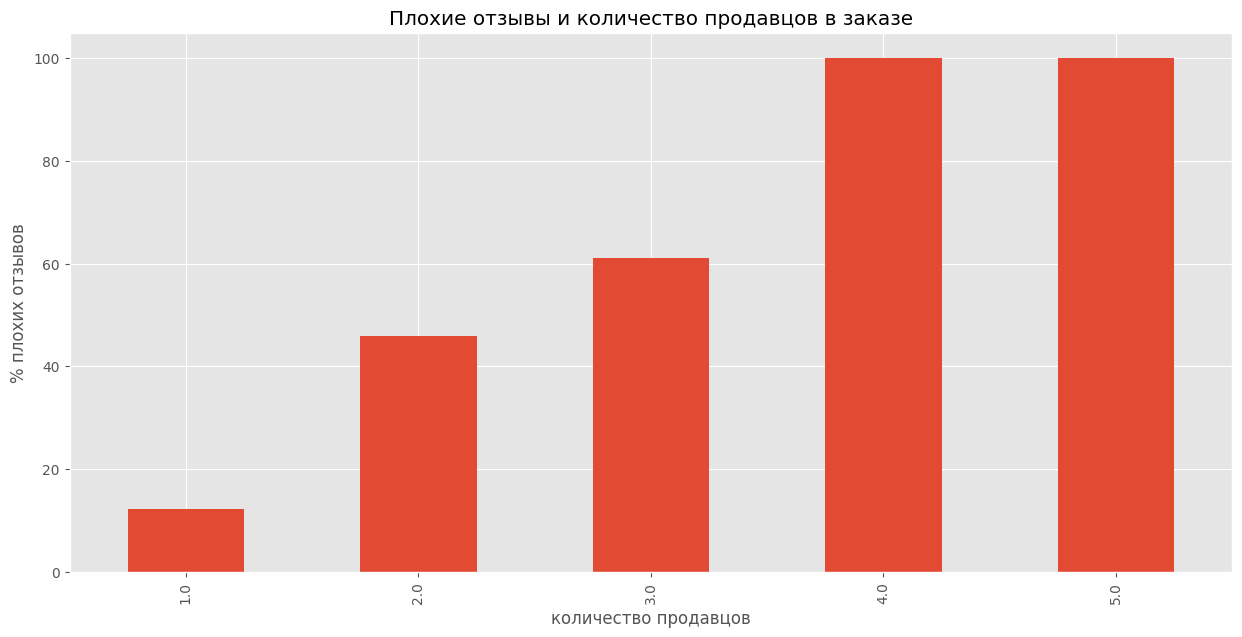

In [ ]:
seller_bad.set_index('unique_sellers')['bad_review_share'].plot(kind='bar')
plt.title('Плохие отзывы и количество продавцов в заказе')
plt.xlabel('количество продавцов')
plt.ylabel('% плохих отзывов')
plt.show()

Если в заказе несколько продавцов, плохих отзывов сильно больше. Для нас это повод задуматься, как оптимизировать логистику, если товары от разных поставщиков едут отдельно, потому что это влияет на итоговый срок доставки всего заказа.

In [ ]:
delivered_orders['price_group'] = pd.qcut(delivered_orders['order_total'], 5, duplicates='drop')
price_bad = delivered_orders.groupby('price_group')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()
price_bad['bad_review_share'] = price_bad['mean'] * 100
price_bad

/var/folders/mr/3x4xnqxd4p1__d5tb6zxhn2w0000gn/T/ipykernel_75525/3383276310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_bad = delivered_orders.groupby('price_group')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()


,price_group,count,mean,bad_review_share
0,"(9.589, 54.374]",19296,0.10,10.19
1,"(54.374, 85.27]",19300,0.11,11.40
2,"(85.27, 128.352]",19291,0.12,12.42
3,"(128.352, 201.82]",19299,0.13,13.47
4,"(201.82, 13664.08]",19292,0.16,15.94


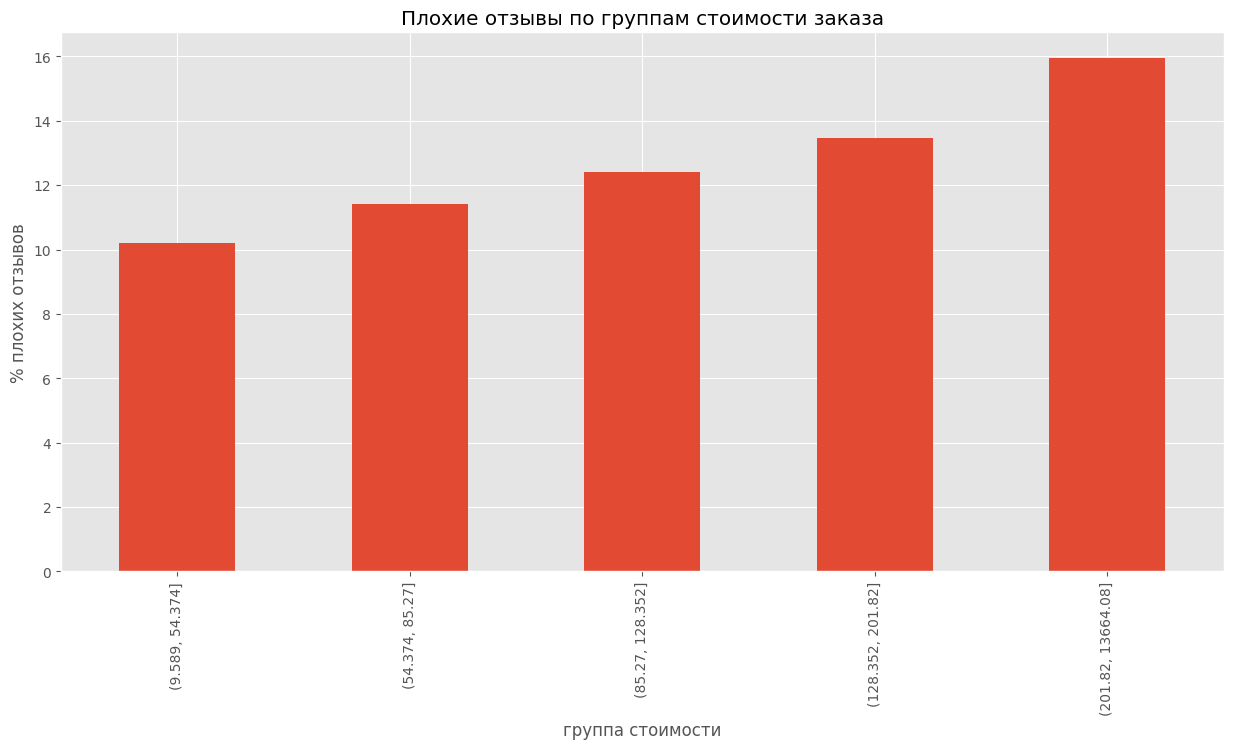

In [ ]:
price_bad.set_index('price_group')['bad_review_share'].plot(kind='bar')
plt.title('Плохие отзывы по группам стоимости заказа')
plt.xlabel('группа стоимости')
plt.ylabel('% плохих отзывов')
plt.show()

У дорогих заказов доля плохих отзывов немного выше. Возможно, там выше ожидания клиента или сложнее доставка самого заказа.

In [ ]:
delivered_orders['installments_group'] = pd.cut(delivered_orders['payment_installments'], bins=[-1, 1, 2, 5, 100])
installments_bad = delivered_orders.groupby('installments_group')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()
installments_bad['bad_review_share'] = installments_bad['mean'] * 100
installments_bad

/var/folders/mr/3x4xnqxd4p1__d5tb6zxhn2w0000gn/T/ipykernel_75525/2446807311.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  installments_bad = delivered_orders.groupby('installments_group')['risk_dissatisfaction'].agg(['count', 'mean']).reset_index()


,installments_group,count,mean,bad_review_share
0,"(-1, 1]",46816,0.12,11.80
1,"(1, 2]",12026,0.12,12.12
2,"(2, 5]",22080,0.13,13.47
3,"(5, 100]",15555,0.15,14.66


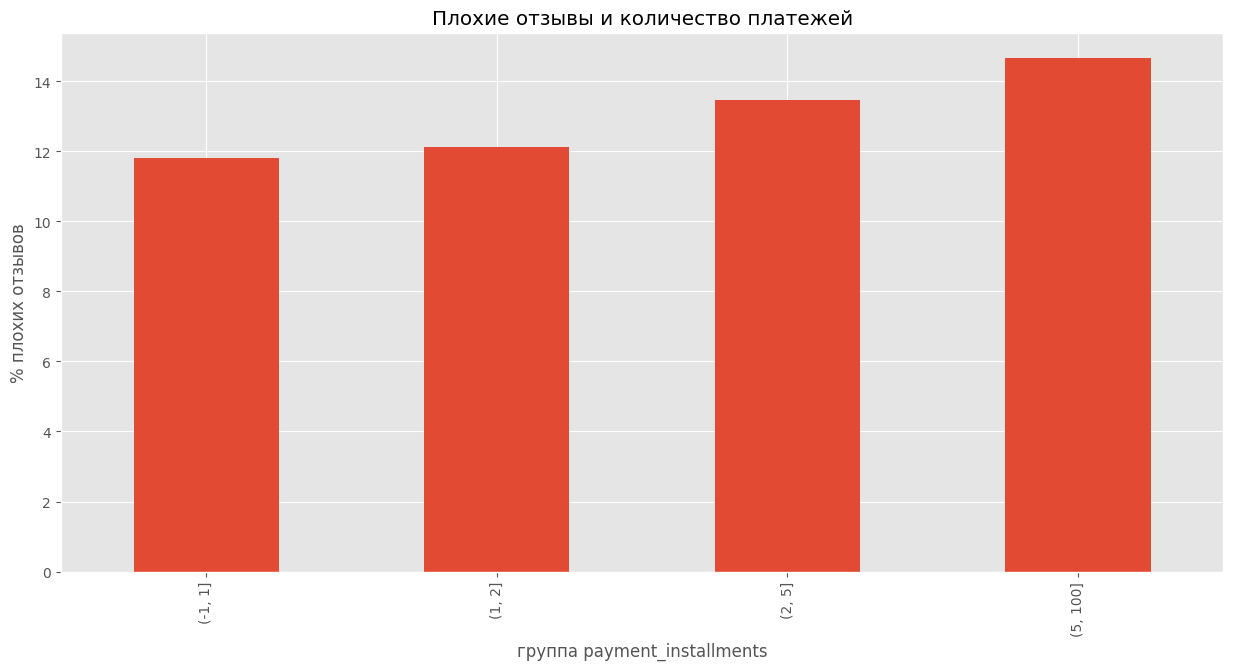

In [ ]:
installments_bad.set_index('installments_group')['bad_review_share'].plot(kind='bar')
plt.title('Плохие отзывы и количество платежей')
plt.xlabel('группа payment_installments')
plt.ylabel('% плохих отзывов')
plt.show()

Рассрочка сама по себе, скорее всего, не причина плохого отзыва. Но она может быть связана с более дорогими заказами, а дорогие заказы немного чаще получают негатив.

Итог по этому блоку: кроме доставки, для модели стоит оставить статус заказа, количество продавцов, стоимость заказа, рассрочку, категорию и географию.

## Раздел 14. Текстовые отзывы

Подготовлю данные для текстовой части проекта.

Идея такая: по тексту отзыва модель должна понимать настроение или тип проблемы. Для разметки можно использовать review_score.

In [ ]:
text_reviews = reviews[reviews['comment_len'] > 0].copy()
text_reviews.shape

(40977, 10)

In [ ]:
text_reviews['sentiment'] = 'neutral'
text_reviews.loc[text_reviews['review_score'] <= 2, 'sentiment'] = 'negative'
text_reviews.loc[text_reviews['review_score'] >= 4, 'sentiment'] = 'positive'

text_reviews[['review_score', 'sentiment', 'review_comment_message']].head()

,review_score,sentiment,review_comment_message
3,5,positive,Recebi bem antes do prazo estipulado.
4,5,positive,Parabéns lojas lannister adorei comprar pela I...
9,4,positive,aparelho eficiente. no site a marca do aparelh...
12,4,positive,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,5,positive,"Vendedor confiável, produto ok e entrega antes..."


In [ ]:
text_reviews['sentiment'].value_counts()

sentiment
positive    26530
negative    10890
neutral      3557
Name: count, dtype: int64

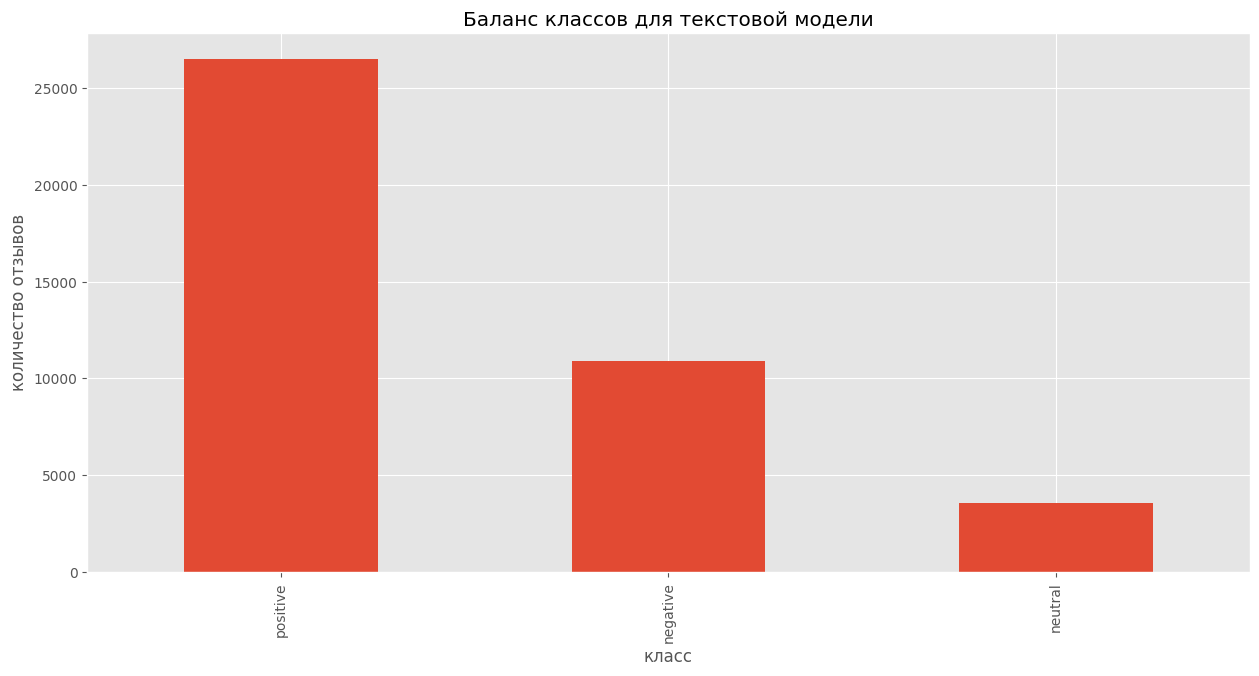

In [ ]:
text_reviews['sentiment'].value_counts().plot(kind='bar')
plt.title('Баланс классов для текстовой модели')
plt.xlabel('класс')
plt.ylabel('количество отзывов')
plt.show()

In [ ]:
text_reviews.groupby('sentiment')['comment_len'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,10890.00,99.33,59.71,1.00,48.00,89.00,150.00,208.00
neutral,3557.00,83.33,58.41,1.00,35.00,70.00,123.00,204.00
positive,26530.00,54.07,43.93,1.00,22.00,43.00,72.00,207.00


In [ ]:
text_reviews[text_reviews['sentiment'] == 'negative'][['review_score', 'review_comment_message']].head(5)

,review_score,review_comment_message
16,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,1,Péssimo
29,1,Não gostei ! Comprei gato por lebre
32,1,Sempre compro pela Internet e a entrega ocorre...
39,1,Nada de chegar o meu pedido.


In [ ]:
text_reviews[text_reviews['sentiment'] == 'positive'][['review_score', 'review_comment_message']].head(5)

,review_score,review_comment_message
3,5,Recebi bem antes do prazo estipulado.
4,5,Parabéns lojas lannister adorei comprar pela I...
9,4,aparelho eficiente. no site a marca do aparelh...
12,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,5,"Vendedor confiável, produto ok e entrega antes..."


Вывод для текстовой модели: тексты есть, но они на португальском. Это повлияет на выбор модели.

### Причины негатива по текстам

Я поискал ключевые слова на португальском, которые хоть как-то говорят об определенной проблеме внутри отзыва.

In [ ]:
text_reviews['text_lower'] = text_reviews['review_comment_message'].str.lower()

text_reviews['reason_delivery'] = text_reviews['text_lower'].str.contains('entrega|entregue|chegou|prazo|atraso|atrasado|demora|demorou', regex=True).astype(int)
text_reviews['reason_not_received'] = text_reviews['text_lower'].str.contains('não recebi|nao recebi|não chegou|nao chegou|não entregue|nao entregue', regex=True).astype(int)
text_reviews['reason_product_problem'] = text_reviews['text_lower'].str.contains('defeito|defeituoso|quebrado|danificado|qualidade|errado|diferente', regex=True).astype(int)
text_reviews['reason_missing_item'] = text_reviews['text_lower'].str.contains('faltou|faltando|incompleto|veio faltando', regex=True).astype(int)
text_reviews['reason_refund_exchange'] = text_reviews['text_lower'].str.contains('troca|devolução|devolucao|reembolso|estorno', regex=True).astype(int)
text_reviews['reason_service'] = text_reviews['text_lower'].str.contains('atendimento|vendedor|loja|suporte', regex=True).astype(int)

reason_cols = ['reason_delivery', 'reason_not_received', 'reason_product_problem',
               'reason_missing_item', 'reason_refund_exchange', 'reason_service']

text_reviews[reason_cols + ['sentiment']].head()

,reason_delivery,reason_not_received,reason_product_problem,reason_missing_item,reason_refund_exchange,reason_service,sentiment
3,1,0,0,0,0,0,positive
4,0,0,0,0,0,1,positive
9,0,0,0,0,0,0,positive
12,0,0,0,0,0,0,positive
15,1,0,0,0,0,1,positive


In [ ]:
reason_by_sentiment = text_reviews.groupby('sentiment')[reason_cols].mean().T * 100
reason_by_sentiment

sentiment,negative,neutral,positive
reason_delivery,39.65,35.79,45.62
reason_not_received,22.03,6.61,0.52
reason_product_problem,12.80,10.49,9.10
reason_missing_item,3.26,3.32,0.37
reason_refund_exchange,7.22,3.74,0.54
reason_service,10.17,7.23,9.66


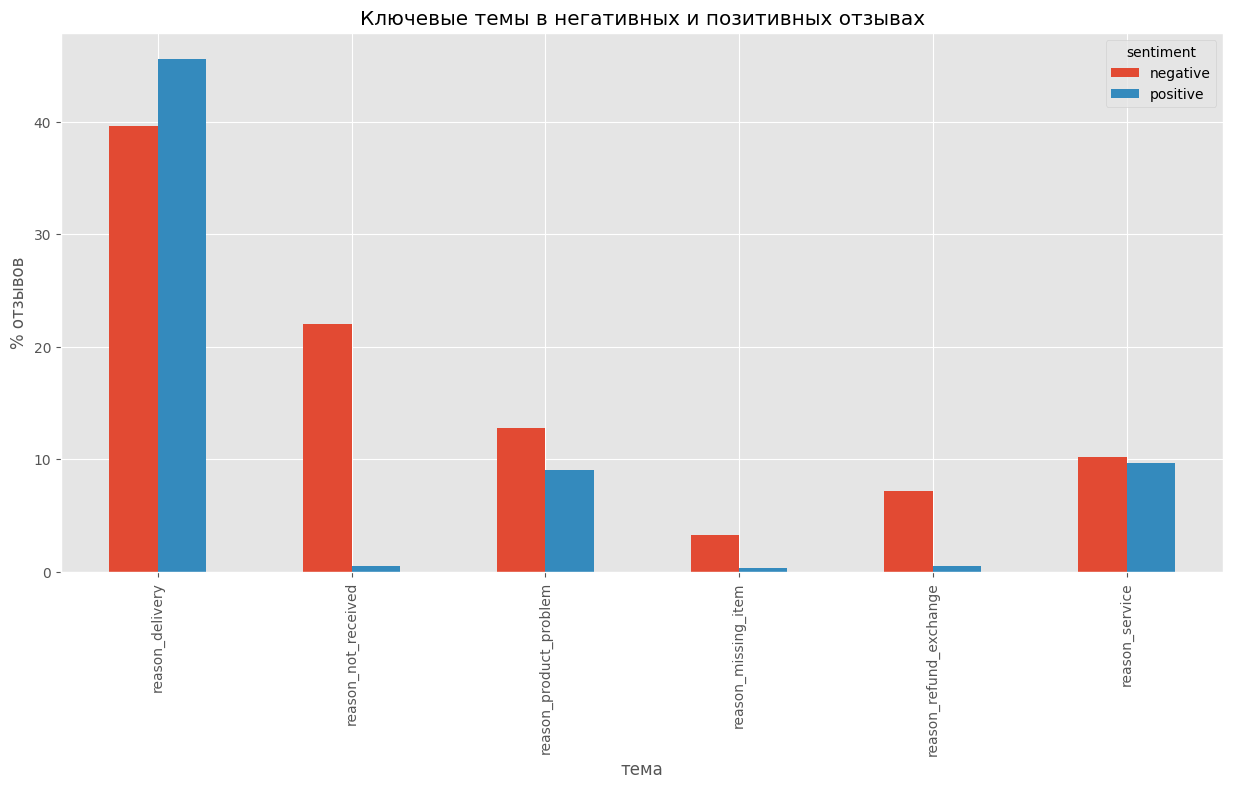

In [ ]:
reason_by_sentiment[['negative', 'positive']].plot(kind='bar')
plt.title('Ключевые темы в негативных и позитивных отзывах')
plt.xlabel('тема')
plt.ylabel('% отзывов')
plt.show()

По текстам видно, что негатив часто связан не только с абстрактной доставкой, но и с более конкретными проблемами. Например, товар не пришел, товар пришел с дефектом, чего-то не хватило, нужен возврат или обмен.

## Раздел 15. Корреляции и признаки для модели

Посмотрю корреляцию числовых признаков с целевой переменной.

In [ ]:
num_cols = [
    'order_total',
    'items_price',
    'freight_value',
    'freight_share',
    'payment_value',
    'payment_installments',
    'order_item_count',
    'unique_products',
    'unique_sellers',
    'delivery_days',
    'estimated_delivery_days',
    'delay_days',
    'is_late',
    'has_text',
    'comment_len',
    'risk_dissatisfaction'
]

corr = order_level[num_cols].corr(numeric_only=True)
corr['risk_dissatisfaction'].sort_values(ascending=False)

risk_dissatisfaction      1.00
comment_len               0.39
is_late                   0.35
delivery_days             0.31
has_text                  0.28
delay_days                0.25
order_item_count          0.11
unique_sellers            0.11
unique_products           0.10
freight_value             0.07
payment_value             0.06
estimated_delivery_days   0.04
order_total               0.04
items_price               0.04
payment_installments      0.03
freight_share             0.01
Name: risk_dissatisfaction, dtype: float64

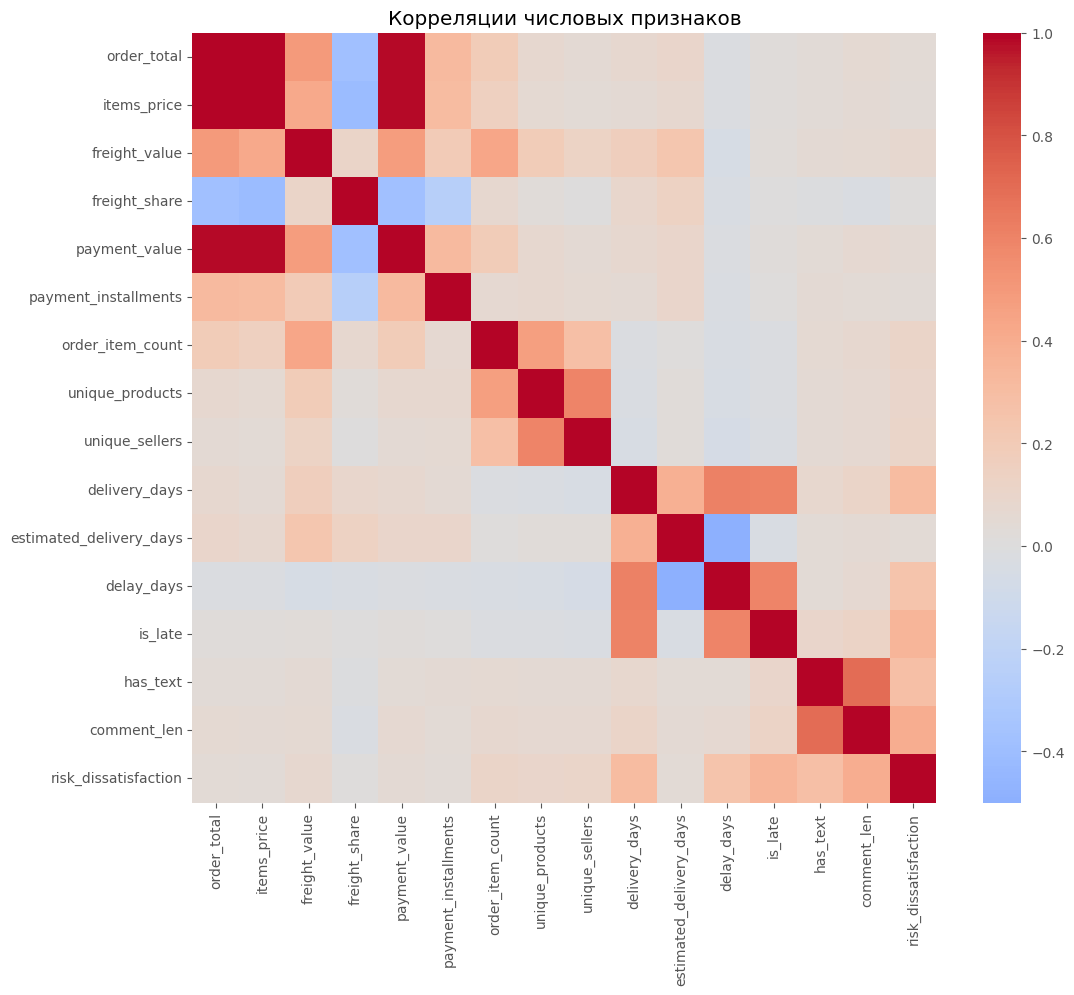

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков')
plt.show()

Пока самые понятные признаки - доставка, задержка, цена заказа, доставка как доля заказа, категория, штат и параметры оплаты.

## Раздел 16. Собираю датасеты для сокомандников

В конце сохраню три таблицы:

1. order_level_dataset.csv — для табличной модели риска недовольства;
2. customer_level_dataset.csv — для анализа клиентов / retention;
3. reviews_text_dataset.csv — для текстовой модели.

In [ ]:
order_model_cols = [
    'order_id',
    'customer_unique_id',
    'customer_state',
    'customer_city',
    'order_purchase_timestamp',
    'order_status',
    'order_total',
    'items_price',
    'freight_value',
    'freight_share',
    'payment_value',
    'payment_installments',
    'payment_type_count',
    'main_payment_type',
    'order_item_count',
    'unique_products',
    'unique_sellers',
    'main_category',
    'delivery_days',
    'estimated_delivery_days',
    'delay_days',
    'is_late',
    'has_text',
    'comment_len',
    'review_score',
    'risk_dissatisfaction',
    'not_delivered',
    'multiple_sellers',
    'high_installments',
    'expensive_order'
]

order_model = order_level[order_model_cols].copy()

order_model = order_model[order_model['review_score'].notna()].copy()

order_model.head()

,order_id,customer_unique_id,customer_state,customer_city,order_purchase_timestamp,order_status,order_total,items_price,freight_value,freight_share,...,delay_days,is_late,has_text,comment_len,review_score,risk_dissatisfaction,not_delivered,multiple_sellers,high_installments,expensive_order
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,2017-10-02 10:56:33,delivered,38.71,29.99,8.72,0.23,...,-8.00,0,1.00,170.00,4.00,0,0,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,barreiras,2018-07-24 20:41:37,delivered,141.46,118.70,22.76,0.16,...,-6.00,0,1.00,20.00,4.00,0,0,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,2018-08-08 08:38:49,delivered,179.12,159.90,19.22,0.11,...,-18.00,0,0.00,0.00,5.00,0,0,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,2017-11-18 19:28:06,delivered,72.20,45.00,27.20,0.38,...,-13.00,0,1.00,105.00,5.00,0,0,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,2018-02-13 21:18:39,delivered,28.62,19.90,8.72,0.30,...,-10.00,0,0.00,0.00,5.00,0,0,0,0,0


In [ ]:
customer_level = order_level.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'order_total': ['sum', 'mean'],
    'review_score': 'mean',
    'risk_dissatisfaction': 'mean',
    'is_late': 'mean',
    'delay_days': 'mean',
    'delivery_days': 'mean',
    'not_delivered': 'mean',
    'multiple_sellers': 'mean',
    'expensive_order': 'mean',
    'order_purchase_timestamp': ['min', 'max']
}).reset_index()

customer_level.columns = [
    'customer_unique_id',
    'n_orders',
    'total_spend',
    'avg_order_value',
    'avg_review_score',
    'bad_review_share',
    'late_order_share',
    'avg_delay_days',
    'avg_delivery_days',
    'not_delivered_share',
    'multiple_seller_order_share',
    'expensive_order_share',
    'first_order_date',
    'last_order_date'
]

customer_level['is_repeat_customer'] = (customer_level['n_orders'] > 1).astype(int)
customer_level['customer_lifetime_days'] = (customer_level['last_order_date'] - customer_level['first_order_date']).dt.days
customer_level.head()

,customer_unique_id,n_orders,total_spend,avg_order_value,avg_review_score,bad_review_share,late_order_share,avg_delay_days,avg_delivery_days,not_delivered_share,multiple_seller_order_share,expensive_order_share,first_order_date,last_order_date,is_repeat_customer,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.00,0.00,0.00,-5.00,6.00,0.00,0.00,0.00,2018-05-10 10:56:27,2018-05-10 10:56:27,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.00,0.00,0.00,-5.00,3.00,0.00,0.00,0.00,2018-05-07 11:11:27,2018-05-07 11:11:27,0,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.00,0.00,0.00,-2.00,25.00,0.00,0.00,0.00,2017-03-10 21:05:03,2017-03-10 21:05:03,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.00,0.00,0.00,-12.00,20.00,0.00,0.00,0.00,2017-10-12 20:29:41,2017-10-12 20:29:41,0,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.00,0.00,0.00,-8.00,13.00,0.00,0.00,0.00,2017-11-14 19:45:42,2017-11-14 19:45:42,0,0


In [ ]:
fav_category = order_level.groupby('customer_unique_id')['main_category'].agg(lambda x: x.mode().iloc[0]).reset_index()
fav_category.columns = ['customer_unique_id', 'favorite_category']

cust_state = order_level.groupby('customer_unique_id')['customer_state'].agg(lambda x: x.mode().iloc[0]).reset_index()
cust_state.columns = ['customer_unique_id', 'customer_state']

customer_level = customer_level.merge(fav_category, on='customer_unique_id', how='left')
customer_level = customer_level.merge(cust_state, on='customer_unique_id', how='left')

retention_cols = first_orders[[
    'customer_unique_id',
    'days_to_next_order',
    'can_check_90_days',
    'returned_90_days',
    'risk_no_return_90d'
]].copy()

customer_level = customer_level.merge(retention_cols, on='customer_unique_id', how='left')
customer_level.head()

,customer_unique_id,n_orders,total_spend,avg_order_value,avg_review_score,bad_review_share,late_order_share,avg_delay_days,avg_delivery_days,not_delivered_share,...,first_order_date,last_order_date,is_repeat_customer,customer_lifetime_days,favorite_category,customer_state,days_to_next_order,can_check_90_days,returned_90_days,risk_no_return_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.00,0.00,0.00,-5.00,6.00,0.00,...,2018-05-10 10:56:27,2018-05-10 10:56:27,0,0,bed_bath_table,SP,NaN,True,False,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.00,0.00,0.00,-5.00,3.00,0.00,...,2018-05-07 11:11:27,2018-05-07 11:11:27,0,0,health_beauty,SP,NaN,True,False,1
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.00,0.00,0.00,-2.00,25.00,0.00,...,2017-03-10 21:05:03,2017-03-10 21:05:03,0,0,stationery,SC,NaN,True,False,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.00,0.00,0.00,-12.00,20.00,0.00,...,2017-10-12 20:29:41,2017-10-12 20:29:41,0,0,telephony,PA,NaN,True,False,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.00,0.00,0.00,-8.00,13.00,0.00,...,2017-11-14 19:45:42,2017-11-14 19:45:42,0,0,telephony,SP,NaN,True,False,1


In [ ]:
reviews_text_dataset = text_reviews[[
    'review_id',
    'order_id',
    'review_score',
    'sentiment',
    'review_comment_message',
    'comment_len',
    'reason_delivery',
    'reason_not_received',
    'reason_product_problem',
    'reason_missing_item',
    'reason_refund_exchange',
    'reason_service'
]].copy()

reviews_text_dataset = reviews_text_dataset.drop_duplicates()

reviews_text_dataset.head()

,review_id,order_id,review_score,sentiment,review_comment_message,comment_len,reason_delivery,reason_not_received,reason_product_problem,reason_missing_item,reason_refund_exchange,reason_service
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,positive,Recebi bem antes do prazo estipulado.,37,1,0,0,0,0,0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,positive,Parabéns lojas lannister adorei comprar pela I...,100,0,0,0,0,0,1
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,positive,aparelho eficiente. no site a marca do aparelh...,174,0,0,0,0,0,0
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,positive,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",45,0,0,0,0,0,0
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,positive,"Vendedor confiável, produto ok e entrega antes...",56,1,0,0,0,0,1


In [ ]:
order_model.to_csv('../data/processed/order_level_dataset.csv', index=False)
customer_level.to_csv('../data/processed/customer_level_dataset.csv', index=False)
reviews_text_dataset.to_csv('../data/processed/reviews_text_dataset.csv', index=False)

## Финальные выводы

Что я понял по EDA:

1. Olist хорошо подходит под нашу идею, потому что тут есть и табличные данные по заказам, и тексты отзывов.
2. Для retention проблема реально есть: повторных клиентов очень мало.
3. Но целевая переменная “не вернулся за 90 дней” получается слишком несбалансированной, поэтому как основную табличную задачу лучше брать риск недовольства.
4. Основной target для модели по работе с табличными данными будет risk_dissatisfaction, то есть review_score меньше или равно 2.
5. Важные признаки: доставка, задержка, статус заказа, чек, стоимость доставки, категория, штат, способ оплаты, количество товаров и количество продавцов.
6. Для текстовой модели можно взять review_comment_message, а label сделать из review_score: negative, neutral, positive